# Topic-1: Estimates of Location
- Mean / trimmed mean / weighted mean
- Median / trimmed median / weighted median


In [ ]:
data = read.csv("input_data\\population_by_country_2020.csv")
head(data)

,Country..or.dependency.,Population..2020.,Yearly.Change,Net.Change,Density..P.Km..,Land.Area..Km..,Migrants..net.,Fert..Rate,Med..Age,Urban.Pop..,World.Share
,<chr>,<int>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,China,1440297825,0.39 %,5540090,153,9388211,-348399,1.7,38,61 %,18.47 %
2,India,1382345085,0.99 %,13586631,464,2973190,-532687,2.2,28,35 %,17.70 %
3,United States,331341050,0.59 %,1937734,36,9147420,954806,1.8,38,83 %,4.25 %
4,Indonesia,274021604,1.07 %,2898047,151,1811570,-98955,2.3,30,56 %,3.51 %
5,Pakistan,221612785,2.00 %,4327022,287,770880,-233379,3.6,23,35 %,2.83 %
6,Brazil,212821986,0.72 %,1509890,25,8358140,21200,1.7,33,88 %,2.73 %


In [ ]:
mean_population <- mean(data$Population..2020.)
trimmed_mean_population <- mean(data$Population..2020., trim = 0.1) # 10% trimmed mean
weighted_mean_land_area <- mean(data$Land.Area..Km.., weights = data$Population..2020.)

median_population <- median(data$Population..2020.)
weighted_median_land_area <- median(data$Land.Area..Km.., weights = data$Population..2020.)

cat("************************************************** Mean ************************************************", "\n")
cat("Mean of population: ", mean_population, "\n")
cat("Trimmed Mean of population: ", trimmed_mean_population, "\n")
cat("Weighted Mean of land area: ", weighted_mean_land_area, "\n")
cat("************************************************** Median ************************************************", "\n")
cat("Median of population: ", median_population, "\n")
cat("Weighted Median of land area: ", weighted_median_land_area, "\n")

************************************************** Mean ************************************************ 
Mean of population:  33227444 
Trimmed Mean of population:  11326178 
Weighted Mean of land area:  553591.8 
************************************************** Median ************************************************ 
Median of population:  5460109 
Weighted Median of land area:  77240 


# Topic-2: Estimates of Variability
1. MAD (Mean Absolute Deviation), Standard Deviation, Variance
2. IQR (Interquartile Range) - Outlier detection

### 1. MAD (Mean Absolute Deviation), Standard Deviation, Variance

In [18]:
# Measures of Variability
mad <- mad(data$Density..P.Km..)
standard_deviation_population <- sd(data$Density..P.Km..)
variance_population <- var(data$Density..P.Km..)

cat("MAD of population density: ", mad, "\n")
cat("Standard Deviation of population density: ", standard_deviation_population, "\n")
cat("Variance of population density: ", variance_population, "\n")

MAD of population density:  103.782 
Standard Deviation of population density:  2331.286 


Variance of population density:  5434894 


### 2. IQR (Interquartile Range) - Outlier detection
- IQR = Q3 - Q1
> Here Q3 is the 75th percentile and Q1 is the 25th percentile, so IQR is the middle 50% range, mostly used for outlier detection and box plots.
- Lower bound = Q1–1.5 * IQR
- Upper bound = Q3 + 1.5 * IQR
> IQR (interquartile range) tells us more detailed information about data spread.
- BoxPlot and Violin Plot

In [58]:
# IQR with lower and upper bounds for outliers
Q1 <- quantile(as.numeric(data$Med..Age), 0.25, na.rm = TRUE)
Q3 <- quantile(as.numeric(data$Med..Age), 0.75, na.rm = TRUE)

IQR = Q3 - Q1

lower_bound <- Q1 - 1.5 * IQR
upper_bound <- Q3 + 1.5 * IQR

cat("IQR of median age: ", IQR, "\n")
cat("Lower Bound for Outliers: ", lower_bound, "\n")
cat("Upper Bound for Outliers: ", upper_bound, "\n")

Warning message in quantile(as.numeric(data$Med..Age), 0.25, na.rm = TRUE):
"NAs introduced by coercion"
Warning message in quantile(as.numeric(data$Med..Age), 0.75, na.rm = TRUE):
"NAs introduced by coercion"


IQR of median age:  17 
Lower Bound for Outliers:  -3.5 
Upper Bound for Outliers:  64.5 


In [ ]:
install.packages("tidyverse", repos = "https://cloud.r-project.org/") # Helps in data processing and processing pipelines
install.packages("ggplot2")
library("tidyverse")

Warning message:
"package 'tidyverse' is in use and will not be installed"
Warning message:
"package 'ggplot2' is in use and will not be installed"
Installing package into 'C:/Users/admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)

Warning message:
"unable to access index for repository https://cran.r-project.org/src/contrib:
  download from 'https://cran.r-project.org/src/contrib/PACKAGES' failed"
Warning message:
"package 'vioplot' is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"


Warning message:
"NAs introduced by coercion"


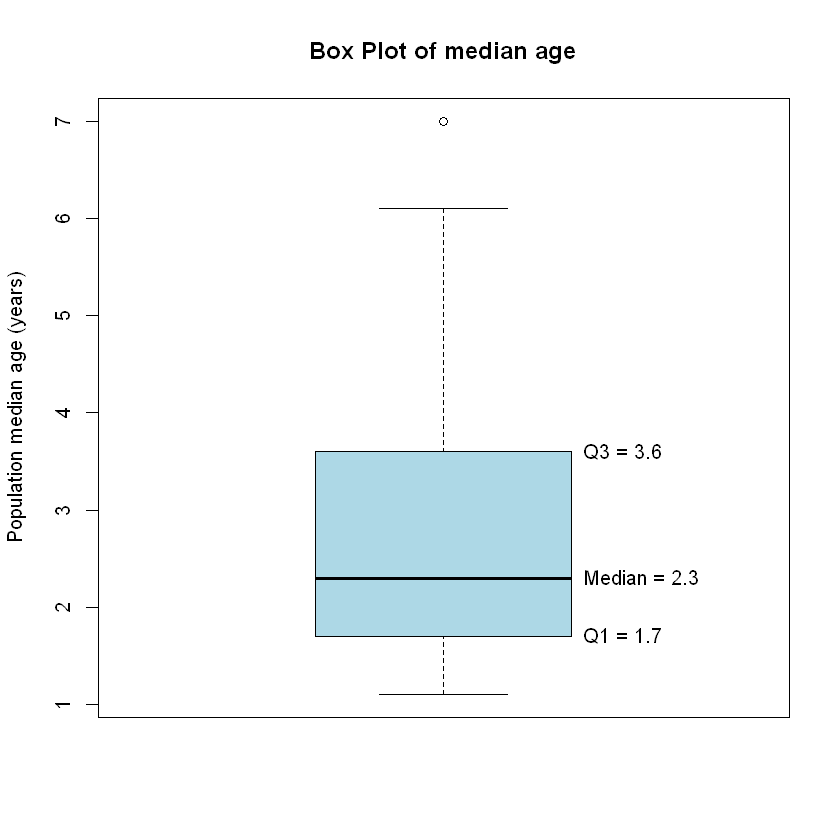

In [80]:
cleaned_med_age = data %>% filter(!is.na(Fert..Rate))
cleaned_med_age$Fert..Rate = as.numeric(cleaned_med_age$Fert..Rate)

boxplot(
    cleaned_med_age$Fert..Rate,
    main = "Box Plot of median age",
    ylab = "Population median age (years)",
    col = "lightblue"
    )

# Calculate quartiles and IQR
Q1  <- quantile(cleaned_med_age$Fert..Rate, 0.25, na.rm = TRUE)
Q3  <- quantile(cleaned_med_age$Fert..Rate, 0.75, na.rm = TRUE)
Median <- median(cleaned_med_age$Fert..Rate, na.rm = TRUE)
IQR_value <- IQR(cleaned_med_age$Fert..Rate, na.rm = TRUE)

# Add text to plot
text(1.2, Q1,  paste("Q1 =", round(Q1,2)), pos = 4)
text(1.2, Median, paste("Median =", round(Median,2)), pos = 4)
text(1.2, Q3,  paste("Q3 =", round(Q3,2)), pos = 4)

Warning message:
"Removed 34 rows containing non-finite outside the scale range
(`stat_ydensity()`)."


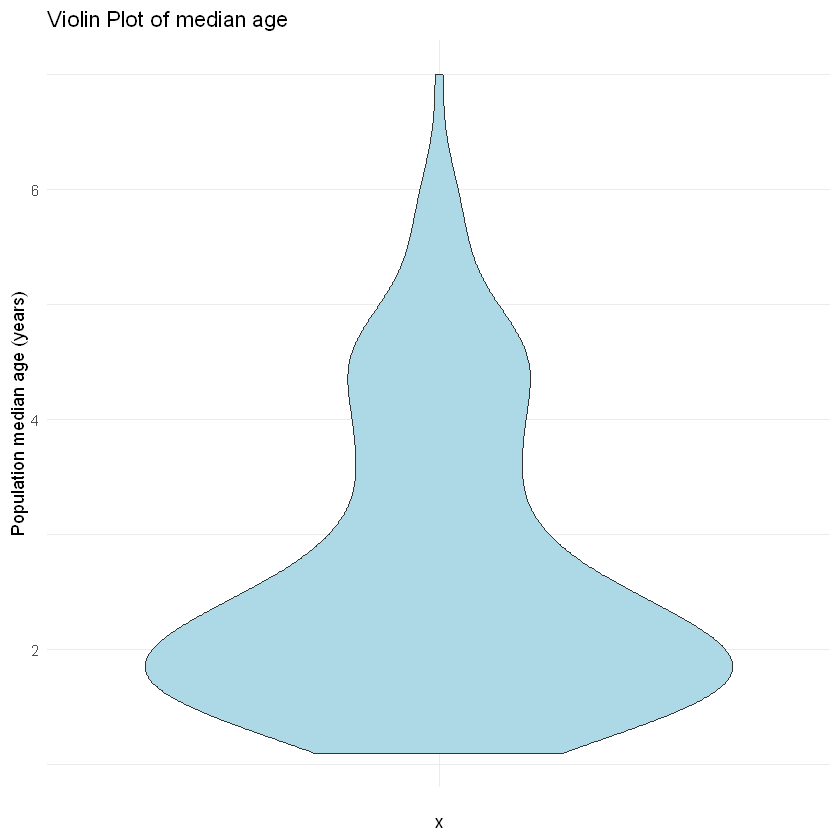

In [83]:
ggplot(cleaned_med_age, aes(x = "", y = Fert..Rate)) +
    geom_violin(fill = "lightblue") +
    labs(title = "Violin Plot of median age", y = "Population median age (years)") +
    theme_minimal() 